In [12]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt

In [13]:
root_dir = r"/Users/yebhonelin/Documents/Practical-ML-by-WAI/6_deep_learning/CNN/cats_and_dogs_filtered"

In [14]:
BATCH_SIZE  = 64

input_img_size = (128,128)
input_shape = (128,128,3)

In [15]:
tf_generator =  tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

In [16]:
train_ds = tf_generator.flow_from_directory(
    root_dir + "/train",
    target_size=input_img_size,
    shuffle=True,
    batch_size=BATCH_SIZE,
    class_mode='categorical'  # or 'categorical'
)

val_ds = tf_generator.flow_from_directory(
    root_dir + "/test",
    target_size=input_img_size,
    shuffle=True,
    batch_size=BATCH_SIZE,
    class_mode='categorical'  # or 'categorical'
)


Found 2752 images belonging to 2 classes.
Found 248 images belonging to 2 classes.


[1. 0.]


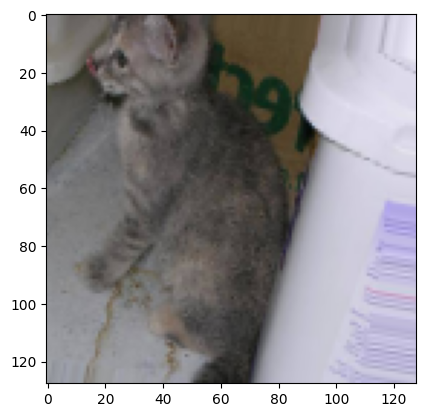

In [17]:
import matplotlib.pyplot as plt
for img,label in train_ds:
    test_img = img
    test_label = label
    break

print(test_label[0])
plt.imshow(test_img[0])

In [18]:
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=input_shape, padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    
    Conv2D(64, (3,3), activation='relu' , padding='same', strides=2), 
    BatchNormalization(),
    MaxPooling2D((2,2)),
    
    Conv2D(128, (3,3), activation='relu', padding='same',strides=2),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    
    Conv2D(256, (3,3), activation='relu', padding='same',strides=2),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='sigmoid')  
])


In [25]:
base_lr = 0.001  
warmup_epochs = 5  
total_epochs = 100 

def lr_scheduler(epoch):
    if epoch < warmup_epochs:
        return base_lr * (epoch + 1) / warmup_epochs
    else:
        cosine_decay = 0.5 * (1 + tf.math.cos(
            (epoch - warmup_epochs) / (total_epochs - warmup_epochs) * 3.1415926535
        ))
        lr = base_lr * cosine_decay
    return float(lr)  

lr_callback = tf.keras.callbacks.LearningRateScheduler(lr_scheduler)

In [26]:
from tensorflow.keras.optimizers import Adam

model.compile(loss='binary_crossentropy',
              optimizer = tf.keras.optimizers.Adam(learning_rate=base_lr, decay=1e-6),
              metrics = ['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 2, 2, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 2, 2, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 587,842 (2.24 MB)

 Trainable params: 586,882 (2.24 MB)

 Non-trainable params: 960 (3.75 KB)

In [27]:
total_epochs = 100
history = model.fit(train_ds,epochs=total_epochs, validation_data=val_ds,verbose=1,callbacks=[lr_callback])

Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 8s 136ms/step - accuracy: 0.5959 - loss: 1.4653 - val_accuracy: 0.6048 - val_loss: 0.9143 - learning_rate: 2.0000e-04
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - accuracy: 0.6031 - loss: 1.5001 - val_accuracy: 0.6008 - val_loss: 1.0036 - learning_rate: 4.0000e-04
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 129ms/step - accuracy: 0.6017 - loss: 1.4490 - val_accuracy: 0.6129 - val_loss: 0.9039 - learning_rate: 6.0000e-04
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 125ms/step - accuracy: 0.5886 - loss: 1.5729 - val_accuracy: 0.4960 - val_loss: 2.0398 - learning_rate: 8.0000e-04
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - accuracy: 0.6446 - loss: 1.3823 - val_accuracy: 0.6331 - val_loss: 0.7615 - learning_rate: 0.0010
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 127ms/step - accuracy: 0.6061 - loss: 1.5590 - val_accuracy: 0.5484 - val_loss: 1.1460 - learning_rate: 0.0010
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 126ms/step - accuracy: 0

In [28]:
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.8101 - loss: 0.4603
Validation Loss: 0.4298
Validation Accuracy: 0.8065


In [29]:
BATCH_SIZE
input_shape

(128, 128, 3)

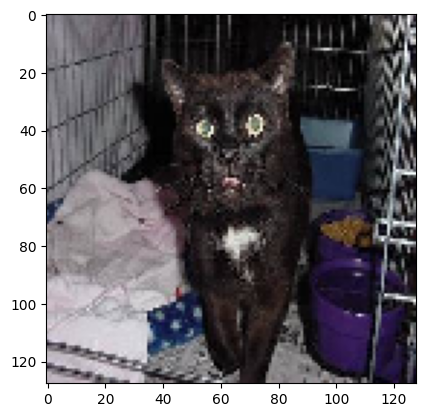

In [115]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = r"/Users/yebhonelin/Documents/Practical-ML-by-WAI/6_deep_learning/CNN/cats_and_dogs_filtered/test/cats/cat.2370.jpg"

img = image.load_img(img_path, target_size=input_img_size)
img_array = image.img_to_array(img)  # shape: (_, _, 3)
img_array = img_array / 255.0        # normalize

img_array = np.expand_dims(img_array, axis=0)  # shape: (1, _, _, 3)
plt.imshow(img_array[0])  # Display the image

In [116]:
train_ds

In [117]:
class_names = train_ds.class_indices

# Convert to dict
class_indices = {name: idx for idx, name in enumerate(class_names)}
print("Class names found:", class_indices)

Class names found: {'cats': 0, 'dogs': 1}


In [118]:
class_names

{'cats': 0, 'dogs': 1}

In [119]:
model.predict(img_array)[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


0.9917971

In [121]:
prediction = model.predict(img_array)[0][0]
class_name = "dogs" if prediction < 0.5 else "cats"

print(f"Predicted class: {class_name} with confidence {prediction:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Predicted class: cats with confidence 0.99


### Model Saving

In [122]:
import os
from dotenv import load_dotenv
load_dotenv()

ML_Summer_School_ID = os.getenv('ML_Summer_School_ID')
print("Your Sudent ID is: " + ML_Summer_School_ID)

Your Sudent ID is: ML_Summer_School_ID_ML054_YeBhoneLin


In [123]:
model.save(f'./binary_classification/{ML_Summer_School_ID}_model.h5')

In [125]:
import json
# Save class names to a text file
with open(f'./binary_classification/{ML_Summer_School_ID}_class_indices.json', 'w') as f:
    class_names = train_ds.class_indices

    # Convert to dict
    class_indices = {name: idx for idx, name in enumerate(class_names)}
    json.dump(class_indices, f)
